# Santa Fe Laser — Exploratory Data Analysis

Goal: get a feel for the dynamics so we can pick sensible window sizes and spot the chaotic-collapse events that historically dominate test-time error.

Series: `data/Xtrain.mat`, key `Xtrain`, shape (1000,), uint8 in [2, 255].

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

from src.data import load_xtrain, make_holdouts
from src.utils import load_yaml

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load + basic stats

In [2]:
x = load_xtrain(ROOT / 'data' / 'Xtrain.mat')
print(f'shape: {x.shape}, dtype: {x.dtype}')
print(f'min  : {x.min():.0f}')
print(f'max  : {x.max():.0f}')
print(f'mean : {x.mean():.2f}')
print(f'std  : {x.std():.2f}')
print(f'median: {np.median(x):.0f}')

shape: (1000,), dtype: float64
min  : 2
max  : 255
mean : 59.89
std  : 46.85
median: 46


## 2. Raw series with candidate collapse events

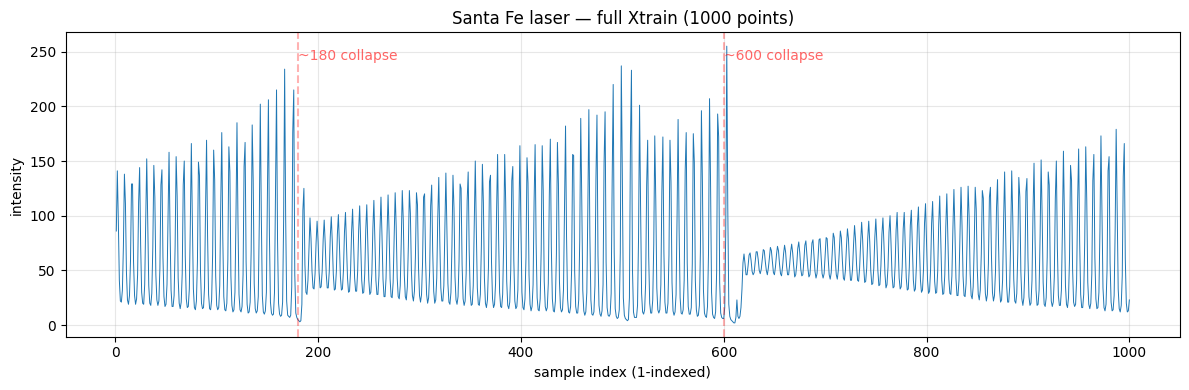

In [3]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, len(x) + 1), x, lw=0.7)
ax.set_xlabel('sample index (1-indexed)')
ax.set_ylabel('intensity')
ax.set_title('Santa Fe laser — full Xtrain (1000 points)')
# Known collapse-event neighbourhoods (from prior literature)
for c in (180, 600):
    ax.axvline(c, color='red', alpha=0.3, ls='--')
ax.text(180, x.max() * 0.95, '~180 collapse', color='red', alpha=0.6)
ax.text(600, x.max() * 0.95, '~600 collapse', color='red', alpha=0.6)
plt.tight_layout(); plt.show()

Zoom into a stable oscillation region and a collapse region to see the local dynamics.

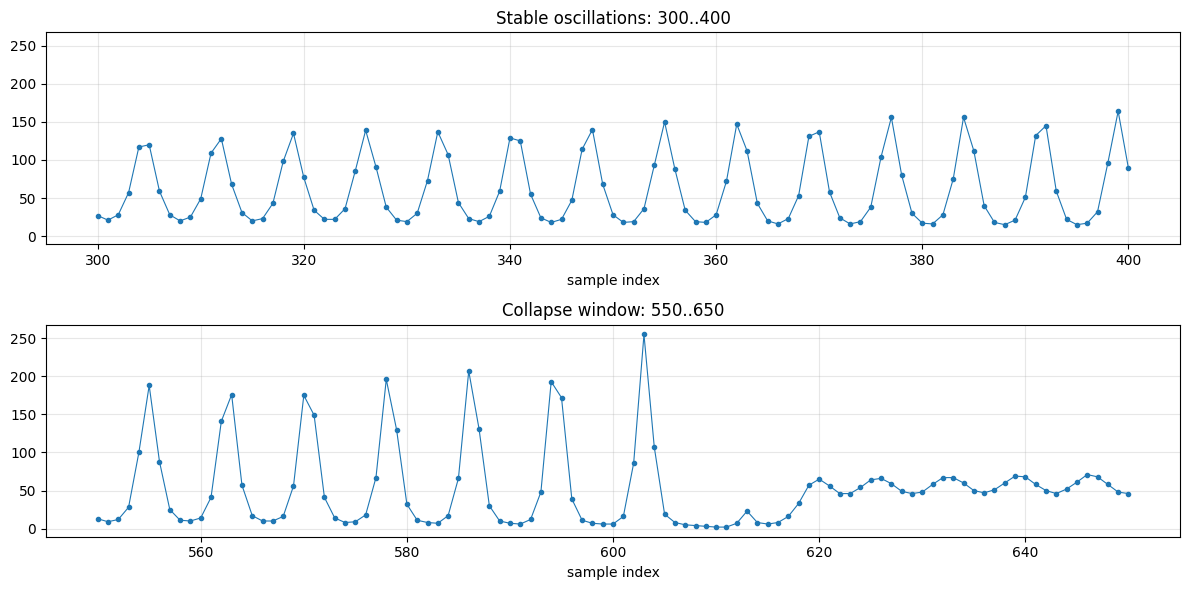

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharey=True)
axes[0].plot(np.arange(300, 401), x[299:400], '.-', lw=0.8)
axes[0].set_title('Stable oscillations: 300..400')
axes[1].plot(np.arange(550, 651), x[549:650], '.-', lw=0.8)
axes[1].set_title('Collapse window: 550..650')
for ax in axes:
    ax.set_xlabel('sample index')
plt.tight_layout(); plt.show()

## 3. Distribution
Long right tail is typical — pulses dominate the high values.

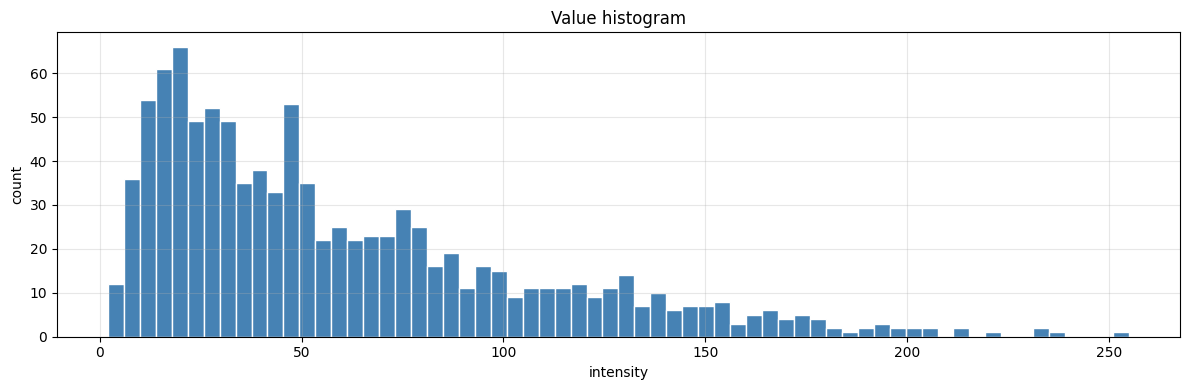

In [5]:
fig, ax = plt.subplots()
ax.hist(x, bins=64, color='steelblue', edgecolor='white')
ax.set_xlabel('intensity'); ax.set_ylabel('count')
ax.set_title('Value histogram')
plt.tight_layout(); plt.show()

## 4. Autocorrelation — what is the dominant period?

ACF lags 0..120. Peaks reveal periodicity. Reported period in the literature is ~7–8 samples between successive peaks.

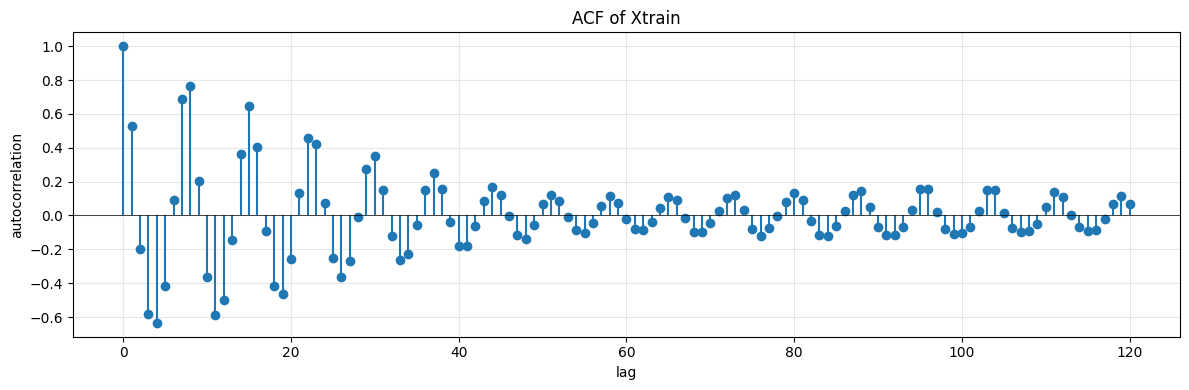

First ACF peak at lag 8 (value 0.768)


In [6]:
def acf(series, max_lag):
    s = (series - series.mean())
    denom = (s ** 2).sum()
    out = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        out[k] = (s[: len(s) - k] * s[k:]).sum() / denom
    return out

lags = 120
rho = acf(x, lags)

fig, ax = plt.subplots()
ax.stem(np.arange(lags + 1), rho, basefmt=' ')
ax.set_xlabel('lag'); ax.set_ylabel('autocorrelation')
ax.set_title('ACF of Xtrain')
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()

# First positive ACF peak after lag 0
peaks, _ = find_peaks(rho[1:], height=0.0)
if len(peaks):
    first_peak = peaks[0] + 1
    print(f'First ACF peak at lag {first_peak} (value {rho[first_peak]:.3f})')
else:
    print('No ACF peak found in the searched range')

## 5. FFT power spectrum

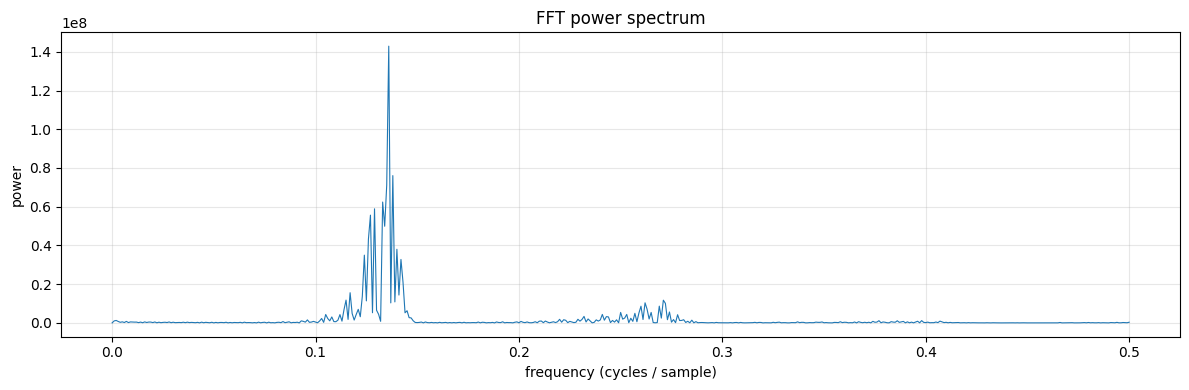

Dominant FFT bin: k=136, freq=0.1360 cycles/sample, period=7.35 samples


In [7]:
from numpy.fft import rfft, rfftfreq

x_centered = x - x.mean()
spec = np.abs(rfft(x_centered)) ** 2
freqs = rfftfreq(len(x), d=1.0)

# Mask out the DC bin
spec[0] = 0

fig, ax = plt.subplots()
ax.plot(freqs, spec, lw=0.8)
ax.set_xlabel('frequency (cycles / sample)')
ax.set_ylabel('power')
ax.set_title('FFT power spectrum')
plt.tight_layout(); plt.show()

# Dominant period from FFT (skip DC)
k_dom = int(np.argmax(spec))
period_fft = 1.0 / freqs[k_dom] if freqs[k_dom] > 0 else float('nan')
print(f'Dominant FFT bin: k={k_dom}, freq={freqs[k_dom]:.4f} cycles/sample, period={period_fft:.2f} samples')

## 6. Synthetic holdouts — the three local validation segments

These mirror the real-test scenario. Plotted in train / inner-val / test colours so we can eyeball whether each holdout test contains a collapse, stable oscillations, or a transition.

In [8]:
cfg = load_yaml(ROOT / 'configs' / 'base.yaml')
holdouts = make_holdouts(
    x,
    cfg['data']['holdouts'],
    window=cfg['window'],
    inner_val_len=cfg['data']['inner_val_len'],
    scaler_name=cfg['data']['scaler'],
)
for name, h in holdouts.items():
    print(f'{name}: train={len(h.train)}, inner_val={len(h.inner_val)}, test={len(h.test)}, '
          f'seed_window={len(h.seed_window)}, test_range=[{h.test_start},{h.test_end}]')

A: train=700, inner_val=100, test=200, seed_window=30, test_range=[801,1000]
B: train=600, inner_val=100, test=200, seed_window=30, test_range=[701,900]
C: train=500, inner_val=100, test=200, seed_window=30, test_range=[601,800]


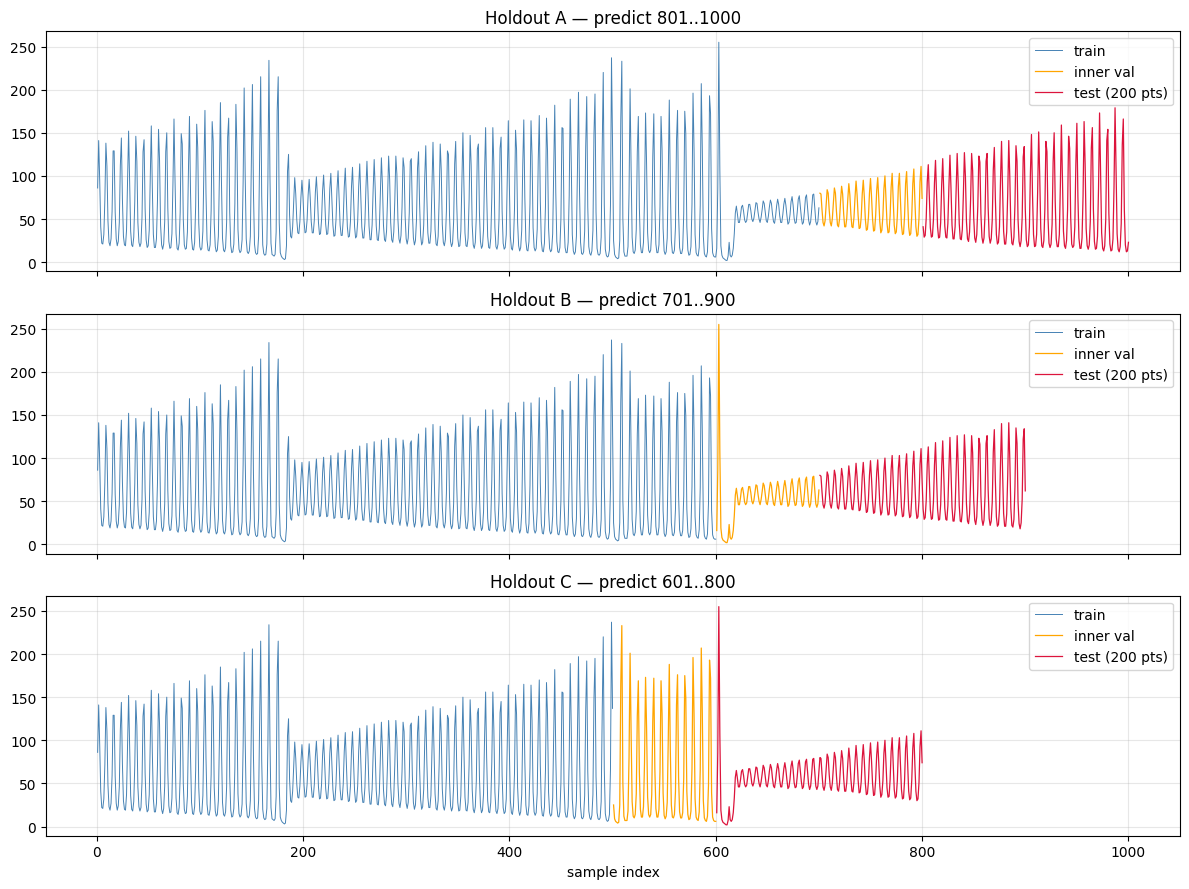

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, (name, h) in zip(axes, holdouts.items()):
    n_train = len(h.train)
    n_inner = len(h.inner_val)
    train_idx = np.arange(1, n_train + 1)
    inner_idx = np.arange(n_train + 1, n_train + n_inner + 1)
    test_idx = np.arange(h.test_start, h.test_end + 1)
    ax.plot(train_idx, h.train, color='steelblue', lw=0.7, label='train')
    ax.plot(inner_idx, h.inner_val, color='orange', lw=0.9, label='inner val')
    ax.plot(test_idx, h.test, color='crimson', lw=0.9, label='test (200 pts)')
    ax.set_title(f'Holdout {name} — predict {h.test_start}..{h.test_end}')
    ax.legend(loc='upper right')
axes[-1].set_xlabel('sample index')
plt.tight_layout(); plt.show()

## 7. What's in each test segment?

Look at the test segments side by side, on their own. Holdout C (601..800) and B (701..900) likely contain the second collapse. A (801..1000) is the most predictive of the real test (1001..1200) since it's the closest in time.

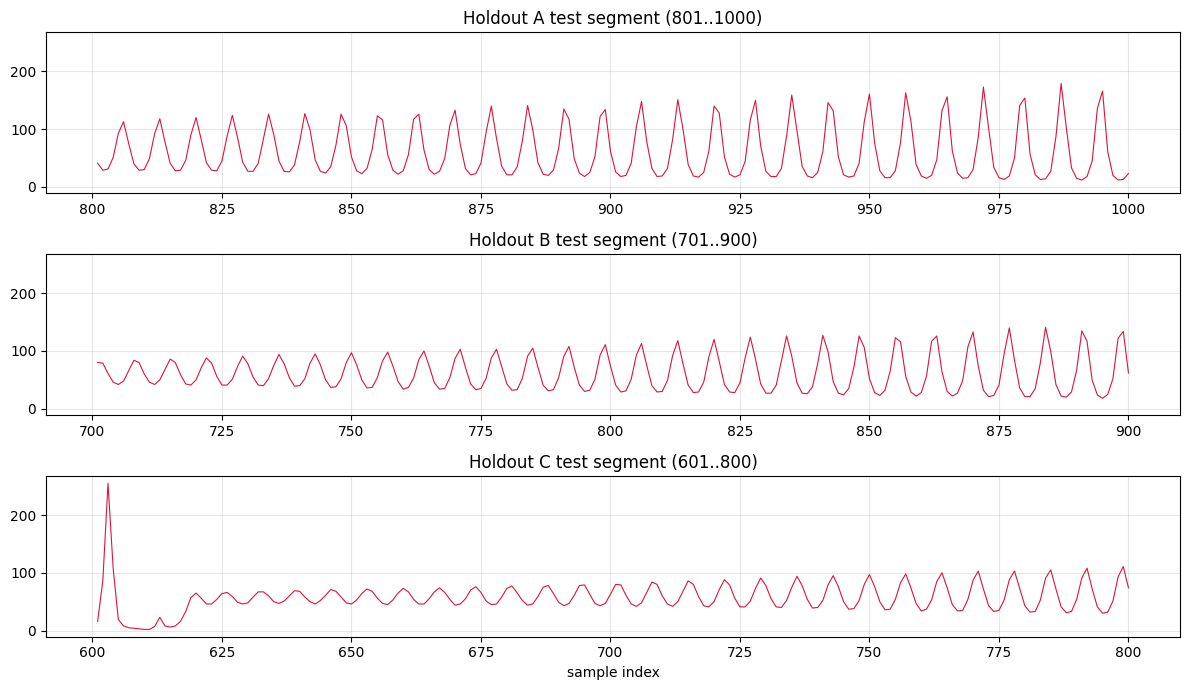

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharey=True)
for ax, (name, h) in zip(axes, holdouts.items()):
    ax.plot(np.arange(h.test_start, h.test_end + 1), h.test, color='crimson', lw=0.8)
    ax.set_title(f'Holdout {name} test segment ({h.test_start}..{h.test_end})')
axes[-1].set_xlabel('sample index')
plt.tight_layout(); plt.show()

## 8. Quick sanity: scaler round-trip

In [11]:
h = holdouts['A']
round_trip = h.scaler.inverse_transform(h.scaler.transform(h.test))
max_err = np.max(np.abs(round_trip - h.test))
print(f'scaler round-trip max abs error on holdout A test: {max_err:.6e}')
print('scaler params:', h.scaler.__dict__)

scaler round-trip max abs error on holdout A test: 2.842171e-14
scaler params: {'low': 0.0, 'high': 1.0, 'data_min_': 2.0, 'data_max_': 255.0}


## Takeaways

- Dominant local period is reported here from FFT and ACF; record both numbers in the team notes. Window sizes below ~10 cannot capture one full cycle.
- Holdouts B and C very likely intersect the second collapse (~600); holdout A is dominated by oscillations. A model that handles both regimes wins.
- The seed window for recursive prediction is the last `window` points BEFORE each test segment — exactly what the real test will have.